In [1]:
!pip install librosa joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import librosa
import joblib

In [3]:
from google.colab import files
uploaded = files.upload()

Saving SensorLog.csv to SensorLog.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving 220727_211424.wav to 220727_211424 (1).wav
Saving 220727_212925.wav to 220727_212925 (1).wav
Saving 220727_214424.wav to 220727_214424 (1).wav
Saving 220727_215922.wav to 220727_215922 (1).wav
Saving 220727_221424.wav to 220727_221424 (1).wav
Saving 220727_222922.wav to 220727_222922 (1).wav
Saving 220727_224423.wav to 220727_224423 (1).wav
Saving 220727_225921.wav to 220727_225921 (1).wav
Saving 220727_231424.wav to 220727_231424 (1).wav
Saving 220727_232922.wav to 220727_232922 (1).wav
Saving 220727_234422.wav to 220727_234422 (1).wav
Saving 220727_235922.wav to 220727_235922 (1).wav
Saving 220728_001421.wav to 220728_001421 (1).wav
Saving 220728_002924.wav to 220728_002924 (1).wav
Saving 220728_004423.wav to 220728_004423 (1).wav
Saving 220728_005922.wav to 220728_005922 (1).wav
Saving 220728_011426.wav to 220728_011426 (1).wav
Saving 220728_012922.wav to 220728_012922 (1).wav
Saving 220728_014422.wav to 220728_014422 (1).wav
Saving 220728_015922.wav to 220728_015922 (1).wav


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
import pandas as pd
df = pd.read_csv('SensorLog.csv', sep=';')

df.head()

,Timestamp,CO2_eq (ppm),TVOC (ppb),TempIn_1 (°C),HumIn_1 (%),TempIn_2 (°C),HumIn_2 (%),TempOut (°C),HumOut (%),Pressure (hPa),Light (-),BeeIn (-),BeeOut (-)
0,22.07.27 21:13:45,400,0,22.0,75.0,21.0,75.0,18.41,67.11,988.61,4,0,0
1,22.07.27 21:28:45,442,164,23.0,78.0,21.0,76.0,18.28,67.00,988.78,1,0,0
2,22.07.27 21:43:45,400,44,23.0,78.0,21.0,76.0,18.10,67.53,988.98,0,0,0
3,22.07.27 21:58:45,400,79,23.0,71.0,21.0,70.0,17.92,67.92,989.22,0,0,0
4,22.07.27 22:13:45,400,13,23.0,68.0,20.0,62.0,17.77,68.22,989.35,0,0,0


In [5]:
df = df.fillna(method='ffill')

# Convert numeric columns if needed
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipykernel_12707/2697187834.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_12707/2697187834.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [8]:
def condition_label(row):
    if row['TempIn_1 (°C)'] > 36 or row['HumIn_1 (%)'] < 50 or row['CO2_eq (ppm)'] > 1000:
        return 1  # Risk
    return 0  # Healthy

df['Condition'] = df.apply(condition_label, axis=1)

In [10]:
def swarm_label(row):
    if row['BeeOut (-)'] > 1.5 * row['BeeIn (-)']:
        return 1
    return 0

df['Swarm'] = df.apply(swarm_label, axis=1)

In [12]:
features = ['TempIn_1 (°C)', 'TempIn_2 (°C)', 'HumIn_1 (%)', 'HumIn_2 (%)',
            'CO2_eq (ppm)', 'TVOC (ppb)', 'Pressure (hPa)', 'Light (-)', 'BeeIn (-)', 'BeeOut (-)']

X = df[features]
y_condition = df['Condition']
y_swarm = df['Swarm']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_condition, test_size=0.2, random_state=42)
_, _, y_train_s, y_test_s = train_test_split(X, y_swarm, test_size=0.2, random_state=42)

In [ ]:
rf_condition = RandomForestClassifier(n_estimators=100, random_state=42)
rf_condition.fit(X_train, y_train_c)

pred_c = rf_condition.predict(X_test)

print("Condition Accuracy:", accuracy_score(y_test_c, pred_c))

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_swarm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_swarm.fit(X_train, y_train_s)

pred_s = rf_swarm.predict(X_test)

print("Swarm Accuracy:", accuracy_score(y_test_s, pred_s))

Swarm Accuracy: 0.98


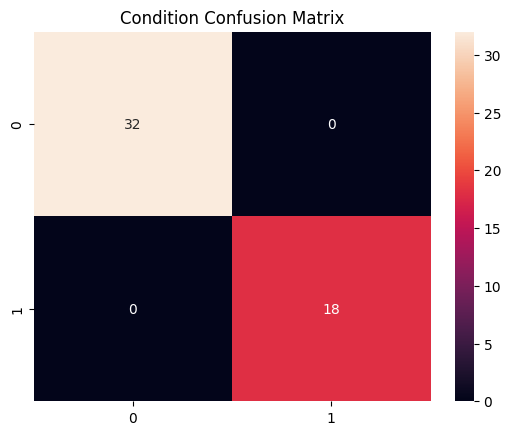

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Define and train rf_condition model
rf_condition = RandomForestClassifier(n_estimators=100, random_state=42)
rf_condition.fit(X_train, y_train_c)

pred_c = rf_condition.predict(X_test)

plt.figure()
sns.heatmap(confusion_matrix(y_test_c, pred_c), annot=True, fmt='d')
plt.title("Condition Confusion Matrix")
plt.show()

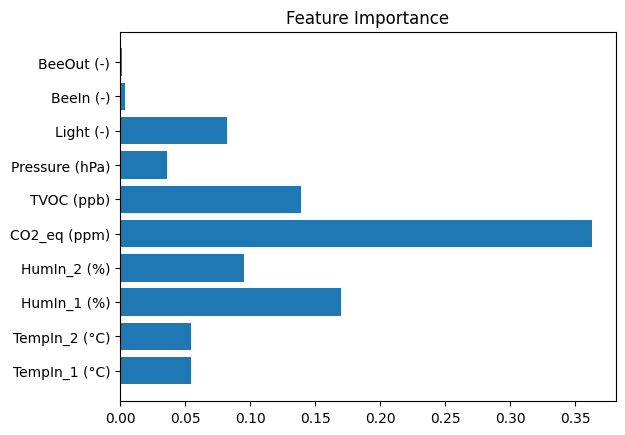

In [22]:
importances = rf_condition.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [25]:
import librosa
import numpy as np

audio, sr = librosa.load('220728_091419.wav', sr=None)

# Energy
energy = np.mean(audio**2)

# Zero Crossing Rate
zcr = np.mean(librosa.feature.zero_crossing_rate(audio))

# Spectral Centroid
centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

print("Energy:", energy)
print("ZCR:", zcr)
print("Centroid:", centroid)

Energy: 7.838337e-05
ZCR: 0.0013659369543073342
Centroid: 2726.392722253025


In [26]:
def queen_detection(energy):
    if energy < 0.02:
        return "Queen Present"
    else:
        return "Queen Absent"

queen_status = queen_detection(energy)

print("Queen Status:", queen_status)

Queen Status: Queen Present


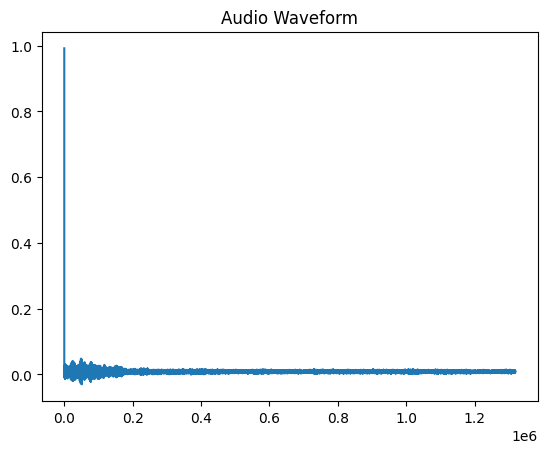

In [27]:
plt.figure()
plt.plot(audio)
plt.title("Audio Waveform")
plt.show()

In [28]:
def smart_beehive(input_data, energy):

    cond = rf_condition.predict([input_data])[0]
    swarm = rf_swarm.predict([input_data])[0]

    queen = queen_detection(energy)

    return {
        "Condition": "Risk" if cond else "Healthy",
        "Swarm Risk": "Yes" if swarm else "No",
        "Queen Status": queen
    }

In [29]:
sample = X.iloc[0]

result = smart_beehive(sample, energy)

print(result)

{'Condition': 'Healthy', 'Swarm Risk': 'No', 'Queen Status': 'Queen Present'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [31]:
import joblib
joblib.dump(rf_condition, 'condition_model.pkl')
joblib.dump(rf_swarm, 'swarm_model.pkl')

['swarm_model.pkl']

In [33]:
from sklearn.metrics import classification_report

print("=== CONDITION MODEL ===")
print("Accuracy:", accuracy_score(y_test_c, pred_c))

print("\nClassification Report:\n")
print(classification_report(y_test_c, pred_c))

=== CONDITION MODEL ===
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        18

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [34]:
print("=== SWARM MODEL ===")
print("Accuracy:", accuracy_score(y_test_s, pred_s))

print("\nClassification Report:\n")
print(classification_report(y_test_s, pred_s))

=== SWARM MODEL ===
Accuracy: 0.98

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      0.80      0.89         5

    accuracy                           0.98        50
   macro avg       0.99      0.90      0.94        50
weighted avg       0.98      0.98      0.98        50



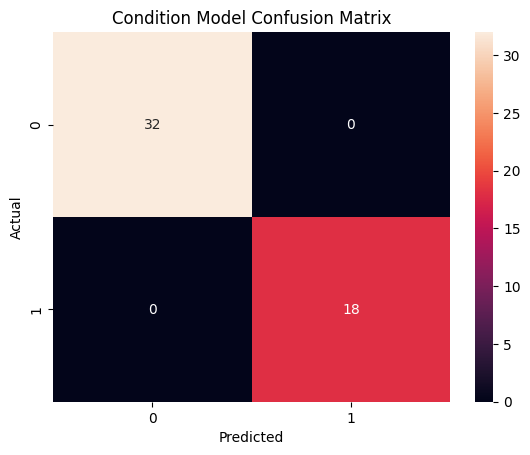

In [35]:
cm_c = confusion_matrix(y_test_c, pred_c)

plt.figure()
sns.heatmap(cm_c, annot=True, fmt='d')
plt.title("Condition Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

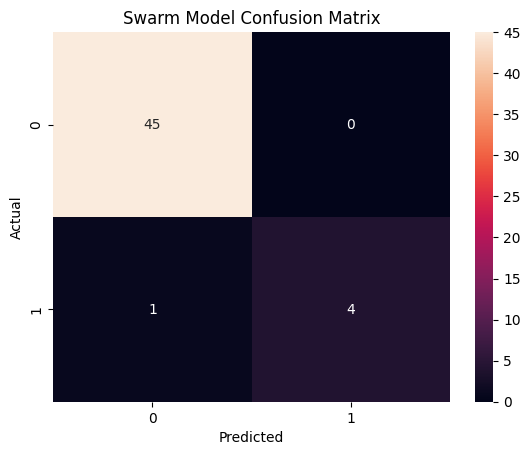

In [36]:
cm_s = confusion_matrix(y_test_s, pred_s)

plt.figure()
sns.heatmap(cm_s, annot=True, fmt='d')
plt.title("Swarm Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
correct = np.sum(pred_c == y_test_c)
total = len(y_test_c)

manual_accuracy = correct / total

print("Manual Accuracy (Condition):", manual_accuracy)

Manual Accuracy (Condition): 1.0


In [39]:
print("===== FINAL RESULTS =====")

print("\nCondition Model Accuracy:", accuracy_score(y_test_c, pred_c))
print("Swarm Model Accuracy:", accuracy_score(y_test_s, pred_s))

print("\nQueen Detection:", queen_status)

sample = X.iloc[0]
final_result = smart_beehive(sample, energy)

print("\nSmart Beehive Prediction:")
print(final_result)

===== FINAL RESULTS =====

Condition Model Accuracy: 1.0
Swarm Model Accuracy: 0.98

Queen Detection: Queen Present

Smart Beehive Prediction:
{'Condition': 'Healthy', 'Swarm Risk': 'No', 'Queen Status': 'Queen Present'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [40]:
df.head()

,Timestamp,CO2_eq (ppm),TVOC (ppb),TempIn_1 (°C),HumIn_1 (%),TempIn_2 (°C),HumIn_2 (%),TempOut (°C),HumOut (%),Pressure (hPa),Light (-),BeeIn (-),BeeOut (-),Condition,Swarm
0,22.07.27 21:13:45,400,0,22.0,75.0,21.0,75.0,18.41,67.11,988.61,4,0,0,0,0
1,22.07.27 21:28:45,442,164,23.0,78.0,21.0,76.0,18.28,67.00,988.78,1,0,0,0,0
2,22.07.27 21:43:45,400,44,23.0,78.0,21.0,76.0,18.10,67.53,988.98,0,0,0,0,0
3,22.07.27 21:58:45,400,79,23.0,71.0,21.0,70.0,17.92,67.92,989.22,0,0,0,0,0
4,22.07.27 22:13:45,400,13,23.0,68.0,20.0,62.0,17.77,68.22,989.35,0,0,0,0,0


In [41]:
print("Energy:", energy)
print("Queen Status:", queen_status)

Energy: 7.838337e-05
Queen Status: Queen Present


In [43]:
import librosa
import numpy as np

audio_features = []

for file in uploaded.keys():
    audio, sr = librosa.load(file, sr=None)

    energy = np.mean(audio**2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

    audio_features.append({
        "file": file,
        "energy": energy,
        "zcr": zcr,
        "centroid": centroid
    })

audio_df = pd.DataFrame(audio_features)
audio_df

,file,energy,zcr,centroid
0,220727_211424 (1).wav,0.000082,0.013322,2880.610221
1,220727_212925 (1).wav,0.000062,0.000247,2933.071422
2,220727_214424 (1).wav,0.000075,0.000071,2776.578721
3,220727_215922 (1).wav,0.000059,0.000146,2849.336112
4,220727_221424 (1).wav,0.000066,0.000027,2771.653861
5,220727_222922 (1).wav,0.000056,0.000000,2937.976782
6,220727_224423 (1).wav,0.000065,0.000003,2799.465669
7,220727_225921 (1).wav,0.000072,0.000000,2822.355969
8,220727_231424 (1).wav,0.000063,0.000000,2687.256281
9,220727_232922 (1).wav,0.000053,0.000000,2925.162091


In [44]:
def queen_label(energy):
    return 0 if energy < 0.02 else 1   # 0 = Queen Present, 1 = Absent

audio_df['Queen'] = audio_df['energy'].apply(queen_label)

audio_df

,file,energy,zcr,centroid,Queen
0,220727_211424 (1).wav,0.000082,0.013322,2880.610221,0
1,220727_212925 (1).wav,0.000062,0.000247,2933.071422,0
2,220727_214424 (1).wav,0.000075,0.000071,2776.578721,0
3,220727_215922 (1).wav,0.000059,0.000146,2849.336112,0
4,220727_221424 (1).wav,0.000066,0.000027,2771.653861,0
5,220727_222922 (1).wav,0.000056,0.000000,2937.976782,0
6,220727_224423 (1).wav,0.000065,0.000003,2799.465669,0
7,220727_225921 (1).wav,0.000072,0.000000,2822.355969,0
8,220727_231424 (1).wav,0.000063,0.000000,2687.256281,0
9,220727_232922 (1).wav,0.000053,0.000000,2925.162091,0


In [45]:
for i, row in audio_df.iterrows():
    status = "Queen Present" if row['Queen'] == 0 else "Queen Absent"
    print(f"{row['file']} → {status}")

220727_211424 (1).wav → Queen Present
220727_212925 (1).wav → Queen Present
220727_214424 (1).wav → Queen Present
220727_215922 (1).wav → Queen Present
220727_221424 (1).wav → Queen Present
220727_222922 (1).wav → Queen Present
220727_224423 (1).wav → Queen Present
220727_225921 (1).wav → Queen Present
220727_231424 (1).wav → Queen Present
220727_232922 (1).wav → Queen Present
220727_234422 (1).wav → Queen Present
220727_235922 (1).wav → Queen Present
220728_001421 (1).wav → Queen Present
220728_002924 (1).wav → Queen Present
220728_004423 (1).wav → Queen Present
220728_005922 (1).wav → Queen Present
220728_011426 (1).wav → Queen Present
220728_012922 (1).wav → Queen Present
220728_014422 (1).wav → Queen Present
220728_015922 (1).wav → Queen Present
220728_021423 (1).wav → Queen Present
220728_022925 (1).wav → Queen Present
220728_024422 (1).wav → Queen Present
220728_025925 (1).wav → Queen Present
220728_031423 (1).wav → Queen Present
220728_032924 (1).wav → Queen Present
220728_03442

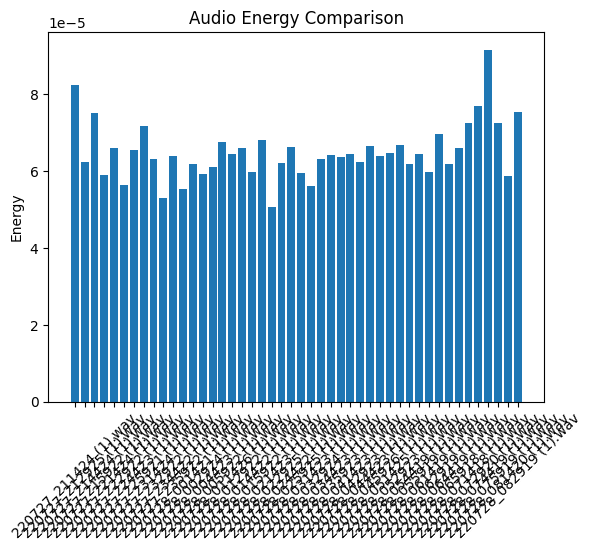

In [46]:
plt.figure()
plt.bar(audio_df['file'], audio_df['energy'])
plt.xticks(rotation=45)
plt.title("Audio Energy Comparison")
plt.ylabel("Energy")
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier

X_audio = audio_df[['energy', 'zcr', 'centroid']]
y_audio = audio_df['Queen']

rf_audio = RandomForestClassifier()
rf_audio.fit(X_audio, y_audio)

RandomForestClassifier()

In [48]:
import joblib

joblib.dump(rf_condition, 'condition_model.pkl')
joblib.dump(rf_swarm, 'swarm_model.pkl')

['swarm_model.pkl']

In [49]:
from google.colab import files

files.download('condition_model.pkl')
files.download('swarm_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
df.to_csv('final_output.csv', index=False)

files.download('final_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

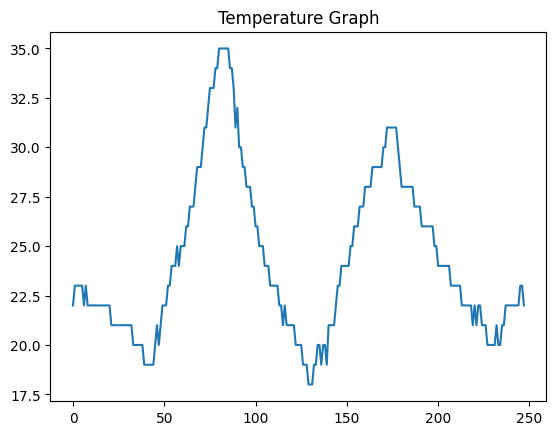

In [52]:
plt.figure()
plt.plot(df['TempIn_1 (°C)'])
plt.title("Temperature Graph")

plt.savefig('temp_graph.png')

from google.colab import files
files.download('temp_graph.png')

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [54]:
joblib.dump(rf_condition, '/content/drive/MyDrive/condition_model.pkl')
df.to_csv('/content/drive/MyDrive/output.csv')

In [55]:
from google.colab import files
uploaded = files.upload()

Saving 220730_034433.wav to 220730_034433.wav
Saving 220730_035933.wav to 220730_035933.wav
Saving 220730_041434.wav to 220730_041434.wav
Saving 220730_042933.wav to 220730_042933.wav
Saving 220730_044435.wav to 220730_044435.wav
Saving 220730_045935.wav to 220730_045935.wav
Saving 220730_051434.wav to 220730_051434.wav
Saving 220730_052936.wav to 220730_052936.wav
Saving 220730_054429.wav to 220730_054429.wav
Saving 220730_055929.wav to 220730_055929.wav
Saving 220730_061431.wav to 220730_061431.wav
Saving 220730_062928.wav to 220730_062928.wav
Saving 220730_064430.wav to 220730_064430.wav
Saving 220730_065929.wav to 220730_065929.wav
Saving 220730_071429.wav to 220730_071429.wav
Saving 220730_072929.wav to 220730_072929.wav
Saving 220730_074430.wav to 220730_074430.wav
Saving 220730_075929.wav to 220730_075929.wav
Saving 220730_081429.wav to 220730_081429.wav
Saving 220730_082929.wav to 220730_082929.wav
Saving 220730_084431.wav to 220730_084431.wav
Saving 220730_085931.wav to 220730

In [66]:
import librosa
import numpy as np

audio_features = []

for file in uploaded.keys():
    audio, sr = librosa.load(file, sr=None)

    energy = np.mean(audio**2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

    audio_features.append({
        "file": file,
        "energy": energy,
        "zcr": zcr,
        "centroid": centroid
    })

audio_df = pd.DataFrame(audio_features)
audio_df

,file,energy,zcr,centroid
0,220729_021428.wav,0.000084,0.008353,2082.104514
1,220729_022927.wav,0.000082,0.008412,2089.135478
2,220729_024427.wav,0.000085,0.008641,2101.831228
3,220729_025928.wav,0.000085,0.010106,2350.789349
4,220729_031430.wav,0.000088,0.010982,2087.988646
5,220729_032928.wav,0.000082,0.007054,2117.225791
6,220729_034429.wav,0.000088,0.011341,2086.486884
7,220729_035928.wav,0.000086,0.009788,2073.886614
8,220729_041428.wav,0.000089,0.011424,2082.965699
9,220729_042928.wav,0.000089,0.011161,2078.911866


In [63]:
import librosa
import numpy as np

audio_features = []

for file in uploaded.keys():
    audio, sr = librosa.load(file, sr=None)

    energy = np.mean(audio**2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

    audio_features.append({
        "file": file,
        "energy": energy,
        "zcr": zcr,
        "centroid": centroid
    })

audio_df = pd.DataFrame(audio_features)
audio_df

,file,energy,zcr,centroid
0,220729_021428.wav,0.000084,0.008353,2082.104514
1,220729_022927.wav,0.000082,0.008412,2089.135478
2,220729_024427.wav,0.000085,0.008641,2101.831228
3,220729_025928.wav,0.000085,0.010106,2350.789349
4,220729_031430.wav,0.000088,0.010982,2087.988646
5,220729_032928.wav,0.000082,0.007054,2117.225791
6,220729_034429.wav,0.000088,0.011341,2086.486884
7,220729_035928.wav,0.000086,0.009788,2073.886614
8,220729_041428.wav,0.000089,0.011424,2082.965699
9,220729_042928.wav,0.000089,0.011161,2078.911866


In [64]:
def queen_label(energy):
    return 0 if energy < 0.02 else 1   # 0 = Queen Present, 1 = Absent

audio_df['Queen'] = audio_df['energy'].apply(queen_label)

audio_df

,file,energy,zcr,centroid,Queen
0,220729_021428.wav,0.000084,0.008353,2082.104514,0
1,220729_022927.wav,0.000082,0.008412,2089.135478,0
2,220729_024427.wav,0.000085,0.008641,2101.831228,0
3,220729_025928.wav,0.000085,0.010106,2350.789349,0
4,220729_031430.wav,0.000088,0.010982,2087.988646,0
5,220729_032928.wav,0.000082,0.007054,2117.225791,0
6,220729_034429.wav,0.000088,0.011341,2086.486884,0
7,220729_035928.wav,0.000086,0.009788,2073.886614,0
8,220729_041428.wav,0.000089,0.011424,2082.965699,0
9,220729_042928.wav,0.000089,0.011161,2078.911866,0


In [65]:
for i, row in audio_df.iterrows():
    status = "Queen Present" if row['Queen'] == 0 else "Queen Absent"
    print(f"{row['file']} → {status}")

220729_021428.wav → Queen Present
220729_022927.wav → Queen Present
220729_024427.wav → Queen Present
220729_025928.wav → Queen Present
220729_031430.wav → Queen Present
220729_032928.wav → Queen Present
220729_034429.wav → Queen Present
220729_035928.wav → Queen Present
220729_041428.wav → Queen Present
220729_042928.wav → Queen Present


In [57]:
from google.colab import files
uploaded = files.upload()

Saving 220729_021428.wav to 220729_021428.wav
Saving 220729_022927.wav to 220729_022927.wav
Saving 220729_024427.wav to 220729_024427.wav
Saving 220729_025928.wav to 220729_025928.wav
Saving 220729_031430.wav to 220729_031430.wav
Saving 220729_032928.wav to 220729_032928.wav
Saving 220729_034429.wav to 220729_034429.wav
Saving 220729_035928.wav to 220729_035928.wav
Saving 220729_041428.wav to 220729_041428.wav
Saving 220729_042928.wav to 220729_042928.wav


In [58]:
import librosa
import numpy as np

audio_features = []

for file in uploaded.keys():
    audio, sr = librosa.load(file, sr=None)

    energy = np.mean(audio**2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

    audio_features.append({
        "file": file,
        "energy": energy,
        "zcr": zcr,
        "centroid": centroid
    })

audio_df = pd.DataFrame(audio_features)
audio_df

,file,energy,zcr,centroid
0,220729_021428.wav,0.000084,0.008353,2082.104514
1,220729_022927.wav,0.000082,0.008412,2089.135478
2,220729_024427.wav,0.000085,0.008641,2101.831228
3,220729_025928.wav,0.000085,0.010106,2350.789349
4,220729_031430.wav,0.000088,0.010982,2087.988646
5,220729_032928.wav,0.000082,0.007054,2117.225791
6,220729_034429.wav,0.000088,0.011341,2086.486884
7,220729_035928.wav,0.000086,0.009788,2073.886614
8,220729_041428.wav,0.000089,0.011424,2082.965699
9,220729_042928.wav,0.000089,0.011161,2078.911866


In [59]:
def queen_label(energy):
    return 0 if energy < 0.02 else 1   # 0 = Queen Present, 1 = Absent

audio_df['Queen'] = audio_df['energy'].apply(queen_label)

audio_df

,file,energy,zcr,centroid,Queen
0,220729_021428.wav,0.000084,0.008353,2082.104514,0
1,220729_022927.wav,0.000082,0.008412,2089.135478,0
2,220729_024427.wav,0.000085,0.008641,2101.831228,0
3,220729_025928.wav,0.000085,0.010106,2350.789349,0
4,220729_031430.wav,0.000088,0.010982,2087.988646,0
5,220729_032928.wav,0.000082,0.007054,2117.225791,0
6,220729_034429.wav,0.000088,0.011341,2086.486884,0
7,220729_035928.wav,0.000086,0.009788,2073.886614,0
8,220729_041428.wav,0.000089,0.011424,2082.965699,0
9,220729_042928.wav,0.000089,0.011161,2078.911866,0


In [60]:
for i, row in audio_df.iterrows():
    status = "Queen Present" if row['Queen'] == 0 else "Queen Absent"
    print(f"{row['file']} → {status}")

220729_021428.wav → Queen Present
220729_022927.wav → Queen Present
220729_024427.wav → Queen Present
220729_025928.wav → Queen Present
220729_031430.wav → Queen Present
220729_032928.wav → Queen Present
220729_034429.wav → Queen Present
220729_035928.wav → Queen Present
220729_041428.wav → Queen Present
220729_042928.wav → Queen Present


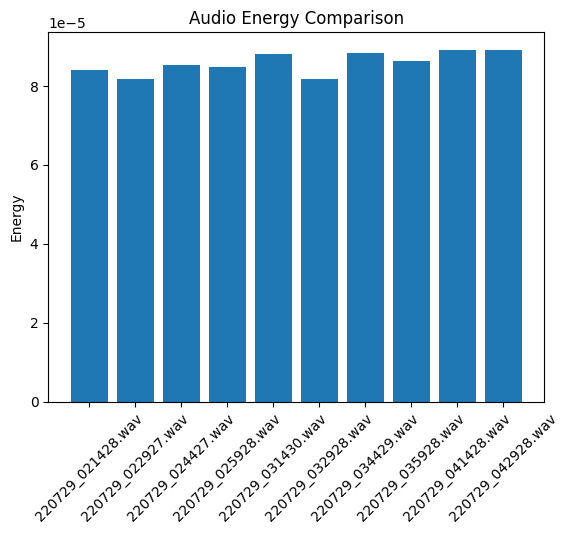

In [61]:
plt.figure()
plt.bar(audio_df['file'], audio_df['energy'])
plt.xticks(rotation=45)
plt.title("Audio Energy Comparison")
plt.ylabel("Energy")
plt.show()

In [62]:
from sklearn.ensemble import RandomForestClassifier

X_audio = audio_df[['energy', 'zcr', 'centroid']]
y_audio = audio_df['Queen']

rf_audio = RandomForestClassifier()
rf_audio.fit(X_audio, y_audio)

RandomForestClassifier()

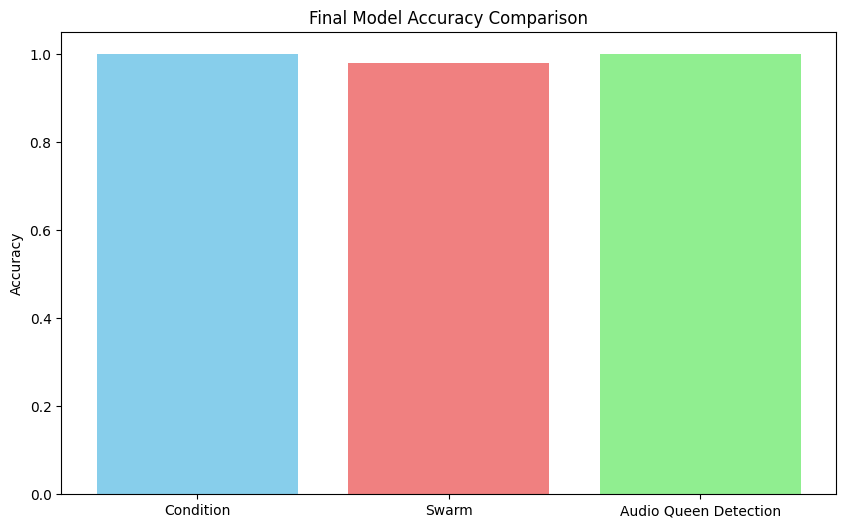

In [68]:
pred_audio = rf_audio.predict(X_audio)

models = ['Condition', 'Swarm', 'Audio Queen Detection']
accuracies = [
    accuracy_score(y_test_c, pred_c),
    accuracy_score(y_test_s, pred_s),
    accuracy_score(y_audio, pred_audio)
]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.show()

In [71]:
print("Energy:", energy)
print("Queen Status:", queen_status)

Energy: 8.9017456e-05
Queen Status: Queen Present


In [72]:
import joblib

joblib.dump(rf_condition, 'condition_model.pkl')
joblib.dump(rf_swarm, 'swarm_model.pkl')

['swarm_model.pkl']

In [73]:
print("===== FINAL RESULTS =====")

print("\nCondition Model Accuracy:", accuracy_score(y_test_c, pred_c))
print("Swarm Model Accuracy:", accuracy_score(y_test_s, pred_s))

print("\nQueen Detection:", queen_status)

sample = X.iloc[0]
final_result = smart_beehive(sample, energy)

print("\nSmart Beehive Prediction:")
print(final_result)

===== FINAL RESULTS =====

Condition Model Accuracy: 1.0
Swarm Model Accuracy: 0.98

Queen Detection: Queen Present

Smart Beehive Prediction:
{'Condition': 'Healthy', 'Swarm Risk': 'No', 'Queen Status': 'Queen Present'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [74]:
from google.colab import files

files.download('condition_model.pkl')
files.download('swarm_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
df.to_csv('final_output.csv', index=False)

files.download('final_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
